# **Практическая работа №4. Построение сверточной нейронной сети для классификации изображений, с использованием BatchNormalization() и Dropout()**

## **Задание 1. Построение сверточной нейронной сети для классификации изображений из датасета CIFAR-100, с использованием BatchNormalization() и Dropout():**



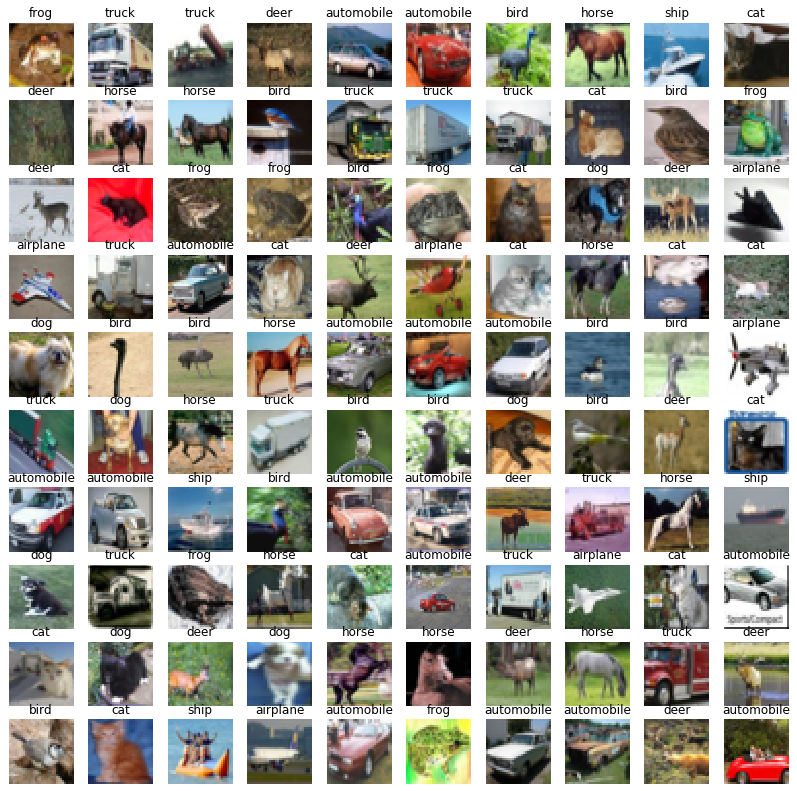

### **1.1. Загрузите исходный датасет. Разделите его на обучающую и тестовую выборки:**



*P.S.: Не забудьте обратить внимание на размерность (shape) исходных данных и при необходимости измените её (см. примеры из предыдущих занятий)*

[Информация о датасете](https://www.cs.toronto.edu/%7Ekriz/cifar.html)

[Техническая документация по использованию датасета в Keras](https://www.tensorflow.org/api_docs/python/tf/keras/datasets/cifar100/load_data)





In [ ]:
from tensorflow.keras import datasets

# label_mode="fine" — все 100 классов, "coarse" — 20 суперклассов
(X_train, y_train), _ = datasets.cifar100.load_data(label_mode="fine")

class_names = [
    "apple","aquarium_fish","baby","bear","beaver","bed","bee","beetle",
    "bicycle","bottle","bowl","boy","bridge","bus","butterfly","camel",
    "can","castle","caterpillar","cattle","chair","chimpanzee","clock",
    "cloud","cockroach","couch","crab","crocodile","cup","dinosaur",
    "dolphin","elephant","flatfish","forest","fox","girl","hamster",
    "house","kangaroo","keyboard","lamp","lawn_mower","leopard","lion",
    "lizard","lobster","man","maple_tree","motorcycle","mountain","mouse",
    "mushroom","oak_tree","orange","orchid","otter","palm_tree","pear",
    "pickup_truck","pine_tree","plain","plate","poppy","porcupine",
    "possum","rabbit","raccoon","ray","road","rocket","rose","sea",
    "seal","shark","shrew","skunk","skyscraper","snail","snake","spider",
    "squirrel","streetcar","sunflower","sweet_pepper","table","tank",
    "telephone","television","tiger","tractor","train","trout","tulip",
    "turtle","wardrobe","whale","willow_tree","wolf","woman","worm"
]

### **1.2. Визуализируйте несколько изображений из датасета:**


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, ax in enumerate(axes):
    ax.imshow(X_train[i])
    ax.set_title(class_names[y_train[i][0]], fontsize=11)
    ax.axis("off")

plt.suptitle("CIFAR-100", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

### **1.3. Произведите нормализацию данных:**

In [ ]:
(X_train, y_train), (X_test, y_test) = datasets.cifar100.load_data()

X_train = X_train.astype("float32") / 255.0
X_test  = X_test.astype("float32")  / 255.0

### **1.4. Создайте модель сверточной нейронной сети для решения поставленной задачи без использования BatchNormalization() и Dropout():**

Имя данной модели: model_1

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model_1 = Sequential([
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),  # → 16x16

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),  # → 8x8

    Conv2D(128, (3, 3), activation='relu', padding='same'),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),  # → 4x4

    Flatten(),
    Dense(512, activation='relu'),
    Dense(100, activation='softmax')  # 100 классов

], name='model_1')

model_1.summary()

Обучите созданную модель

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

callbacks = [
    ModelCheckpoint(
        filepath='model_1_best.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),

    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,  # откат к лучшим весам
        verbose=1
    )
]

model_1.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_1 = model_1.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=callbacks,
    verbose=1
)

### **1.5. Создайте модель сверточной нейронной сети для решения поставленной задачи с использованием BatchNormalization():**

Имя данной модели: model_2

In [ ]:
from tensorflow.keras.layers import Activation, BatchNormalization

model_2 = Sequential([
    Conv2D(32, (3, 3), padding='same', input_shape=(32, 32, 3)),
    BatchNormalization(),
    Activation('relu'),
    Conv2D(32, (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),  # → 16x16

    Conv2D(64, (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    Conv2D(64, (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),  # → 8x8

    Conv2D(128, (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    Conv2D(128, (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),  # → 4x4


    Flatten(),
    Dense(512),
    BatchNormalization(),
    Activation('relu'),
    Dense(100, activation='softmax')

], name='model_2')

model_2.summary()

Обучите созданную модель

In [ ]:
callbacks = [
    ModelCheckpoint(
        filepath='model_2_best.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),

    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,  # откат к лучшим весам
        verbose=1
    )
]

model_2.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_2 = model_2.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=callbacks,
    verbose=1
)

### **1.6. Создайте модель сверточной нейронной сети для решения поставленной задачи с использованием Dropout():**

Имя данной модели: model_3

In [ ]:
from tensorflow.keras.layers import Dropout

model_3 = Sequential([
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),  # → 16x16
    Dropout(0.25),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),  # → 8x8
    Dropout(0.25),

    Conv2D(128, (3, 3), activation='relu', padding='same'),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),  # → 4x4
    Dropout(0.25),

    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),          # более агрессивный Dropout на Dense
    Dense(100, activation='softmax')

], name='model_3')

model_3.summary()

Обучите созданную модель

In [ ]:
callbacks = [
    ModelCheckpoint(
        filepath='model_3_best.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),

    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,  # откат к лучшим весам
        verbose=1
    )
]

model_3.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_3 = model_3.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=callbacks,
    verbose=1
)

### **1.7. Создайте модель сверточной нейронной сети для решения поставленной задачи с использованием Dropout() и BatchNormalization().**

См. рекомендации [здесь](https://stackoverflow.com/questions/39691902/ordering-of-batch-normalization-and-dropout) и [здесь](https://www.kaggle.com/code/ryanholbrook/dropout-and-batch-normalization/)

Имя данной модели: model_4

In [ ]:
model_4 = Sequential([
    Conv2D(32, (3, 3), padding='same', input_shape=(32, 32, 3)),
    BatchNormalization(),
    Activation('relu'),
    Conv2D(32, (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),  # → 16x16
    Dropout(0.25),

    Conv2D(64, (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    Conv2D(64, (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),  # → 8x8
    Dropout(0.25),

    Conv2D(128, (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    Conv2D(128, (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),  # → 4x4
    Dropout(0.25),

    Flatten(),
    Dense(512),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),
    Dense(100, activation='softmax')
], name='model_4')

model_4.summary()

Обучите созданную модель

In [ ]:
callbacks = [
    ModelCheckpoint(
        filepath='model_4_best.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),

    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,  # откат к лучшим весам
        verbose=1
    )
]

model_4.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_4 = model_4.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=callbacks,
    verbose=1
)

### **Задание 1.8. Пойстройте график обучения для каждой модели. Сделайте выводы по каждому из них. Подведите итог и выделите наиболее удачную модель:**

In [ ]:
import numpy as np

histories = {
    'model_1 (без BN и Dropout)': history_1,
    'model_2 (только BN)':        history_2,
    'model_3 (только Dropout)':   history_3,
    'model_4 (BN + Dropout)':     history_4,
}

fig, axes = plt.subplots(4, 2, figsize=(14, 20))
fig.suptitle('Сравнение обучения моделей на CIFAR-100', fontsize=16, y=1.01)

for i, (name, hist) in enumerate(histories.items()):
    epochs = range(1, len(hist.history['accuracy']) + 1)

    # --- График Accuracy ---
    ax_acc = axes[i][0]
    ax_acc.plot(epochs, hist.history['accuracy'],     label='Train Acc', linewidth=2)
    ax_acc.plot(epochs, hist.history['val_accuracy'], label='Val Acc',   linewidth=2, linestyle='--')
    ax_acc.set_title(f'{name}\nAccuracy', fontsize=11)
    ax_acc.set_xlabel('Эпоха')
    ax_acc.set_ylabel('Accuracy')
    ax_acc.legend()
    ax_acc.grid(True, alpha=0.3)

    # --- График Loss ---
    ax_loss = axes[i][1]
    ax_loss.plot(epochs, hist.history['loss'],     label='Train Loss', linewidth=2)
    ax_loss.plot(epochs, hist.history['val_loss'], label='Val Loss',   linewidth=2, linestyle='--')
    ax_loss.set_title(f'{name}\nLoss', fontsize=11)
    ax_loss.set_xlabel('Эпоха')
    ax_loss.set_ylabel('Loss')
    ax_loss.legend()
    ax_loss.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

1) Сильное переобучение, крайне высокая ошибка
2) BatchNormalization помогает, но совсем немного. Неюзабельно
3) Результаты значительно выше. Можно сказать, что даже без BatchNormalization уже очень эффективно. Да-да, не удивляйтесь.
4) Самая лучшая связка эвер.

*\*Водянистые рассуждения в духе Толяна на полчаса\** Лучшая модель - очевидно, связка дропаута и БН.

### **1.9. Визуализируйте карты активации модели с BatchNorm() и Dropout(),отдельно по 5 классам (на Ваш выбор):**

In [ ]:
from tensorflow.keras.layers import AveragePooling2D

def visualize_act_map(model, img):
    target_types = (Conv2D,
                    MaxPooling2D,
                    AveragePooling2D)

    target_names = []
    activations  = []

    x = img[:1]  # берём один пример
    for layer in model.layers:
        x = layer(x)
        if isinstance(layer, target_types):
            target_names.append(layer.name)
            activations.append(x.numpy() if hasattr(x, 'numpy') else np.array(x))

    if not activations:
        print("В модели нет свёрточных/пулинг-слоёв для визуализации.")
        return

    for layer_name, layer_activation in zip(target_names, activations):
        n_features   = layer_activation.shape[-1]
        size         = layer_activation.shape[1]
        n_cols       = n_features // 16 + int(n_features % 16 > 0)
        display_grid = np.zeros((size * n_cols, size * 16))

        for col in range(n_cols):
            for row in range(16):
                idx = col * 16 + row
                if idx >= n_features:
                    continue
                channel_image  = layer_activation[0, :, :, idx].copy()
                channel_image -= channel_image.mean()
                std = channel_image.std()
                if std == 0:
                    channel_image += 1e-8
                channel_image /= channel_image.std()
                channel_image *= 64
                channel_image += 128
                channel_image  = np.clip(channel_image, 0, 255).astype('uint8')
                display_grid[col * size:(col + 1) * size,
                             row * size:(row + 1) * size] = channel_image

        scale = 1. / size
        fig, ax = plt.subplots(figsize=(scale * display_grid.shape[1],
                                        scale * display_grid.shape[0]))
        ax.set_title(layer_name)
        ax.grid(False)
        ax.imshow(display_grid, aspect='auto', cmap='viridis')

        for i in range(1, n_cols):
            ax.axhline(y=i * size - 0.5, color='white', linewidth=2)
        for i in range(1, 16):
            ax.axvline(x=i * size - 0.5, color='white', linewidth=2)

        plt.show()



# Загрузка данных
(X_train, y_train), _ = datasets.cifar100.load_data()
X_train_norm = X_train.astype("float32") / 255.0

# 5 выбранных классов
CLASSES = {
    0:  "apple",
    19: "cattle",
    29: "dinosaur",
    51: "mushroom",
    86: "tiger"
}

# Визуализация для каждого класса
for class_id, class_name in CLASSES.items():

    # Первое изображение нужного класса
    idx   = np.where(y_train.flatten() == class_id)[0][0]
    image = X_train_norm[idx]                    # (32, 32, 3)
    inp   = np.expand_dims(image, axis=0)        # (1, 32, 32, 3) — нужен батч

    # Заголовок с оригинальным изображением
    fig, ax = plt.subplots(1, 1, figsize=(2, 2))
    ax.imshow(image)
    ax.set_title(f'Класс: {class_name} (id={class_id})', fontsize=10)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

    print(f"\n{'='*55}")
    print(f"  Карты активаций → {class_name.upper()} (class_id={class_id})")
    print(f"{'='*55}\n")

    # Вызов функции
    visualize_act_map(model_4, inp)

## **Задание 2. Загрузите Ваш датасет из предыдущей работы. Разделите его на обучающую и тестовую выборки. Обучите модель классификации с применением BatchNorm() и Dropout(). Сравните точность с моделями, обученными Вами ранее. Визуализируйте карты активаций.**

In [ ]:
!mkdir -p data
!curl -L -o data/flowers_dataset.zip "https://www.kaggle.com/api/v1/datasets/download/rahmasleam/flowers-dataset"
!unzip -q data/flowers_dataset.zip -d data/flowers_dataset

In [ ]:
!ls data/flowers_dataset/flower_photos

DATASET_PATH = "data/flowers_dataset/flower_photos"

In [ ]:
import os

root = 'data/flowers_dataset'

# Найти папку с классами автоматически
for dirpath, dirnames, filenames in os.walk(root):
    if filenames:
        print(f"{dirpath}: {len(filenames)} файлов")
        break

# Показать найденные классы
for entry in os.scandir(root):
    if entry.is_dir():
        subdir = list(os.scandir(entry.path))
        # Если внутри ещё папки — это и есть классы
        if any(e.is_dir() for e in subdir):
            print("Классы:", [e.name for e in subdir if e.is_dir()])

In [ ]:
import tensorflow as tf
from tensorflow.keras.utils import image_dataset_from_directory

# Автоматически определяем папку с классами
import pathlib
dataset_path = None
for p in pathlib.Path(root).rglob('*'):
    if p.is_dir() and any(x.is_dir() for x in p.iterdir()):
        dataset_path = str(p)
        break

print(f"Путь к датасету: {dataset_path}")

IMG_SIZE   = (32, 32)   # под архитектуру model_4
BATCH_SIZE = 64
SEED       = 42

# 80% train, 20% val
train_ds = image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset='training',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int'
)

val_ds = image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset='validation',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int'
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"Классы ({num_classes}): {class_names}")

In [ ]:
# Нормализация [0, 255] → [0, 1]
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds   = val_ds.map(lambda x, y:   (normalization_layer(x), y))

# Кэширование и предзагрузка для ускорения
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [ ]:
from tensorflow.keras import models, layers

# num_classes берётся автоматически из датасета
model_4 = models.Sequential([

    # Блок 1
    layers.Conv2D(32, (3, 3), padding='same', input_shape=(32, 32, 3)),
    layers.BatchNormalization(), layers.Activation('relu'),
    layers.Conv2D(32, (3, 3), padding='same'),
    layers.BatchNormalization(), layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Блок 2
    layers.Conv2D(64, (3, 3), padding='same'),
    layers.BatchNormalization(), layers.Activation('relu'),
    layers.Conv2D(64, (3, 3), padding='same'),
    layers.BatchNormalization(), layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Блок 3
    layers.Conv2D(128, (3, 3), padding='same'),
    layers.BatchNormalization(), layers.Activation('relu'),
    layers.Conv2D(128, (3, 3), padding='same'),
    layers.BatchNormalization(), layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Классификатор
    layers.Flatten(),
    layers.Dense(512),
    layers.BatchNormalization(), layers.Activation('relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')  # ← автоматически

], name='model_4')

model_4.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_4.summary()

In [ ]:
from tensorflow.keras import callbacks

cb_list = [
    callbacks.ModelCheckpoint(
        'model_4_flowers_best.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    )
]

history = model_4.fit(
    train_ds,
    epochs=30,
    validation_data=val_ds,
    callbacks=cb_list
)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'],     label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc', linestyle='--')
plt.title('Accuracy — Flowers dataset'); plt.legend(); plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss', linestyle='--')
plt.title('Loss — Flowers dataset'); plt.legend(); plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
import os
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from glob import glob
from PIL import Image
from tensorflow.keras.models import load_model

# Загрузка моделей
flowers_cnn  = load_model('flowers_cnn_best.keras')
best_alexnet = load_model('best_alexnet.keras')
classifier   = load_model('classifier.h5')
model_4      = load_model('model_4_flowers_best.keras')
DATASET_PATH = 'data/flowers_dataset/flower_photos'

# Маппинги классов
sorted_classes  = sorted([
    cls for cls in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, cls))
])
listdir_classes = [
    cls for cls in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, cls))
]

# flowers_cnn / best_alexnet — порядок os.listdir
cnn_class_to_idx = {cls: i for i, cls in enumerate(listdir_classes)}
# classifier / model_4 — порядок sorted (image_dataset_from_directory сортирует)
clf_class_to_idx = {cls: i for i, cls in enumerate(sorted_classes)}

print('sorted_classes :', sorted_classes)
print('listdir_classes:', listdir_classes)

# Выборка 15 изображений

all_images   = glob(os.path.join(DATASET_PATH, '*', '*.*'))
random.seed(42)
sample_paths = random.sample(all_images, 15)
true_labels  = [os.path.basename(os.path.dirname(p)) for p in sample_paths]

y_true_cnn = np.array([cnn_class_to_idx[l] for l in true_labels])
y_true_clf = np.array([clf_class_to_idx[l]  for l in true_labels])

# Предобработка
def load_for_cnn(paths, model):
    size = model.input_shape[1:3]
    X = []
    for p in paths:
        img = Image.open(p).convert('RGB').resize((size[1], size[0]))
        X.append(np.array(img).astype('float32') / 255.0)
    return np.stack(X)

def load_for_flat(paths, size=(64, 64)):
    X = []
    for p in paths:
        img = cv2.imread(p)
        img = cv2.resize(img, size).astype('float32') / 255.0
        X.append(img.reshape(-1))
    return np.stack(X)

X_flowers    = load_for_cnn(sample_paths, flowers_cnn)
X_alexnet    = load_for_cnn(sample_paths, best_alexnet)
X_classifier = load_for_flat(sample_paths)
X_model4     = load_for_cnn(sample_paths, model_4)

# Предсказания

pred_flowers    = np.argmax(flowers_cnn.predict(X_flowers,   verbose=0), axis=1)
pred_alexnet    = np.argmax(best_alexnet.predict(X_alexnet,  verbose=0), axis=1)
pred_classifier = np.argmax(classifier.predict(X_classifier, verbose=0), axis=1)
pred_model4     = np.argmax(model_4.predict(X_model4,        verbose=0), axis=1)

acc_flowers    = np.mean(pred_flowers    == y_true_cnn)
acc_alexnet    = np.mean(pred_alexnet    == y_true_cnn)
acc_classifier = np.mean(pred_classifier == y_true_clf)
acc_model4     = np.mean(pred_model4     == y_true_clf)

# Таблица результатов
print(f"\nflowers_cnn  accuracy : {acc_flowers:.3f}")
print(f"best_alexnet accuracy : {acc_alexnet:.3f}")
print(f"classifier   accuracy : {acc_classifier:.3f}")
print(f"model_4      accuracy : {acc_model4:.3f}")

print(f"\n{'#':<3} {'файл':<28} {'истина':<12} {'flowers':<14} {'alexnet':<14} {'classifier':<14} {'model_4'}")
print('-' * 105)
for i, path in enumerate(sample_paths):
    true_name = true_labels[i]
    f_name    = listdir_classes[pred_flowers[i]]
    a_name    = listdir_classes[pred_alexnet[i]]
    c_name    = sorted_classes[pred_classifier[i]]
    m4_name   = sorted_classes[pred_model4[i]]

    cf  = '✅' if pred_flowers[i]    == y_true_cnn[i] else '❌'
    ca  = '✅' if pred_alexnet[i]    == y_true_cnn[i] else '❌'
    cc  = '✅' if pred_classifier[i] == y_true_clf[i] else '❌'
    cm4 = '✅' if pred_model4[i]     == y_true_clf[i] else '❌'

    print(f"{i+1:<3} {os.path.basename(path)[:27]:<28} "
          f"{true_name:<12} "
          f"{cf} {f_name:<12} "
          f"{ca} {a_name:<12} "
          f"{cc} {c_name:<12} "
          f"{cm4} {m4_name}")

# Визуализация карт активаций
def visualize_act_map(model, img):
    target_types = (tf.keras.layers.Conv2D,
                    tf.keras.layers.MaxPooling2D,
                    tf.keras.layers.AveragePooling2D)
    target_names = []
    activations  = []

    x = img[:1]
    for layer in model.layers:
        x = layer(x)
        if isinstance(layer, target_types):
            target_names.append(layer.name)
            activations.append(x.numpy() if hasattr(x, 'numpy') else np.array(x))

    if not activations:
        print("  ⚠️  Нет свёрточных слоёв для визуализации.")
        return

    for layer_name, layer_activation in zip(target_names, activations):
        n_features   = layer_activation.shape[-1]
        size         = layer_activation.shape[1]
        n_cols       = n_features // 16 + int(n_features % 16 > 0)
        display_grid = np.zeros((size * n_cols, size * 16))

        for col in range(n_cols):
            for row in range(16):
                idx = col * 16 + row
                if idx >= n_features:
                    continue
                channel_image  = layer_activation[0, :, :, idx].copy()
                channel_image -= channel_image.mean()
                std = channel_image.std()
                if std == 0:
                    channel_image += 1e-8
                channel_image /= channel_image.std()
                channel_image *= 64
                channel_image += 128
                channel_image  = np.clip(channel_image, 0, 255).astype('uint8')
                display_grid[col * size:(col + 1) * size,
                             row * size:(row + 1) * size] = channel_image

        scale = 1. / size
        fig, ax = plt.subplots(figsize=(scale * display_grid.shape[1],
                                        scale * display_grid.shape[0]))
        ax.set_title(layer_name)
        ax.grid(False)
        ax.imshow(display_grid, aspect='auto', cmap='viridis')
        for i in range(1, n_cols):
            ax.axhline(y=i * size - 0.5, color='white', linewidth=2)
        for i in range(1, 16):
            ax.axvline(x=i * size - 0.5, color='white', linewidth=2)
        plt.show()

sample_per_class = {}
for path in all_images:
    cls = os.path.basename(os.path.dirname(path))
    if cls not in sample_per_class:
        sample_per_class[cls] = path
    if len(sample_per_class) == 5:
        break

for cls, path in sample_per_class.items():
    img_flowers = load_for_cnn([path], flowers_cnn)
    img_alexnet = load_for_cnn([path], best_alexnet)

    orig = Image.open(path).convert('RGB').resize((128, 128))
    plt.imshow(orig); plt.title(f'Класс: {cls}'); plt.axis('off'); plt.show()

    print(f"\n{'='*55}")
    print(f"  flowers_cnn — {cls.upper()}")
    print(f"{'='*55}")
    visualize_act_map(flowers_cnn, img_flowers)

    print(f"\n{'='*55}")
    print(f"  best_alexnet — {cls.upper()}")
    print(f"{'='*55}")
    visualize_act_map(best_alexnet, img_alexnet)

    print(f"\n{'='*55}")
    print(f"  classifier — {cls.upper()} (нет Conv-слоёв)")
    print(f"{'='*55}")
    visualize_act_map(classifier, img_flowers)
